In [1]:
# ============================================================
# 06_time_trends.ipynb
# Time trends Analysis - Core drop-off visualisation
# ============================================================
# Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from db_connection import get_engine

engine = get_engine()
print("Connected.")

Connected.


In [2]:
# Load monthly data
query_monthly = """
SELECT
    DATE_TRUNC('month', event_time)                  AS month,
    COUNT(*) FILTER (WHERE event_type = 'view')      AS total_views,
    COUNT(*) FILTER (WHERE event_type = 'cart')      AS total_carts,
    COUNT(*) FILTER (WHERE event_type = 'purchase')  AS total_purchases,
    COUNT(DISTINCT CASE WHEN event_type = 'view'
          THEN user_id END)                          AS unique_viewers,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase'
          THEN user_id END)                          AS unique_buyers,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)              AS conversion_rate,
    ROUND(COALESCE(SUM(price) FILTER
          (WHERE event_type = 'purchase'), 0), 2)        AS monthly_revenue
FROM events_clean
GROUP BY DATE_TRUNC('month', event_time)
ORDER BY month;
"""
monthly_df = pd.read_sql(query_monthly, engine)
monthly_df['month'] = pd.to_datetime(monthly_df['month'])
monthly_df['month'] = monthly_df['month'].dt.strftime('%Y-%m')
print(monthly_df[['month', 'unique_viewers', 'unique_buyers',
                   'conversion_rate', 'monthly_revenue']])

     month  unique_viewers  unique_buyers  conversion_rate  monthly_revenue
0  2020-09           15309            627             4.10         96353.01
1  2020-10           84096           3796             4.51        562590.39
2  2020-11           92529           4328             4.68        787886.24
3  2020-12           72074           3869             5.37        813068.01
4  2021-01           81154           4771             5.88       1488410.57
5  2021-02           74506           4341             5.83       1376805.70


In [14]:
# Load hourly data
query_hourly = """
SELECT
    EXTRACT(HOUR FROM event_time)        AS hour,
    COUNT(DISTINCT CASE 
        WHEN event_type = 'view' THEN user_id 
    END)                                 AS total_views,
    COUNT(DISTINCT CASE 
        WHEN event_type = 'purchase' THEN user_id 
    END)                                AS total_purchases,
    ROUND(
        COUNT(DISTINCT CASE 
            WHEN event_type = 'purchase' THEN user_id END) * 100.0 /
        NULLIF(
            COUNT(DISTINCT CASE 
                WHEN event_type = 'view' THEN user_id END), 0
        ), 2
    )                                 AS conversion_rate,
    ROUND(SUM(price) FILTER 
        (WHERE event_type = 'purchase'), 2
    )                                  AS total_revenue
FROM events_clean
GROUP BY hour
ORDER BY hour;
"""
hourly_df = pd.read_sql(query_hourly, engine)
hourly_df['hour'] = hourly_df['hour'].astype(int)
print(hourly_df)

    hour  total_views  total_purchases  conversion_rate  total_revenue
0      0         6020              224             3.72       71119.27
1      1         6085              232             3.81       48855.13
2      2         6676              274             4.10       55409.47
3      3         8935              388             4.34       86117.00
4      4        12495              533             4.27       99933.66
5      5        17061              830             4.86      155351.43
6      6        22514             1203             5.34      226600.58
7      7        26380             1385             5.25      258770.50
8      8        28361             1559             5.50      273187.94
9      9        29412             1651             5.61      302129.86
10    10        29897             1700             5.69      325458.01
11    11        30223             1691             5.60      339988.70
12    12        29637             1566             5.28      312623.32
13    

In [11]:
# Cell 4: Load day of week data
query_dow = """
SELECT
    EXTRACT(DOW FROM event_time)                     AS day_num,
    TO_CHAR(event_time, 'Day')                       AS day_name,
    COUNT(*) FILTER (WHERE event_type = 'view')      AS total_views,
    COUNT(*) FILTER (WHERE event_type = 'purchase')  AS total_purchases,
    ROUND(
        COUNT(DISTINCT CASE WHEN event_type = 'purchase'
              THEN user_id END) * 100.0 /
        NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'view'
              THEN user_id END), 0), 2)              AS conversion_rate,
    ROUND(SUM(price) FILTER
          (WHERE event_type = 'purchase'), 2)        AS total_revenue
FROM events_clean
GROUP BY day_num, day_name
ORDER BY day_num;
"""
dow_df = pd.read_sql(query_dow, engine)
dow_df['day_name'] = dow_df['day_name'].str.strip()
print(dow_df)

   day_num   day_name  total_views  total_purchases  conversion_rate  \
0      0.0     Sunday       110711             5127             4.92   
1      1.0     Monday       119827             5706             5.18   
2      2.0    Tuesday       116602             5543             5.23   
3      3.0  Wednesday       114249             5584             5.21   
4      4.0   Thursday       113122             5300             5.14   
5      5.0     Friday       112844             5219             4.97   
6      6.0   Saturday       105588             4864             5.01   

   total_revenue  
0      727984.81  
1      771508.19  
2      757783.42  
3      725881.92  
4      734626.33  
5      732784.48  
6      674544.77  


In [5]:
# Cell 5: Load weekly data
query_weekly = """
WITH weekly_stats AS (
    SELECT
        DATE_TRUNC('week', event_time)               AS week_start,
        COUNT(*) FILTER (WHERE event_type = 'view')      AS views,
        COUNT(*) FILTER (WHERE event_type = 'purchase')  AS purchases,
        ROUND(SUM(price) FILTER
              (WHERE event_type = 'purchase'), 2)    AS revenue
    FROM events_clean
    GROUP BY DATE_TRUNC('week', event_time)
)
SELECT
    week_start,
    views,
    purchases,
    revenue,
    COALESCE(LAG(revenue) OVER (ORDER BY week_start), 0) AS prev_week_revenue,
    COALESCE(
        ROUND(
            (revenue - LAG(revenue) OVER (ORDER BY week_start)) * 100.0 /
            NULLIF(LAG(revenue) OVER (ORDER BY week_start), 0), 2
        ), 0)                                            AS revenue_growth_pct
FROM weekly_stats
ORDER BY week_start;
"""
weekly_df = pd.read_sql(query_weekly, engine)
weekly_df['week_start'] = pd.to_datetime(weekly_df['week_start'])
print(f"Weeks: {len(weekly_df)}")
print(weekly_df.head())

Weeks: 23
  week_start  views  purchases    revenue  prev_week_revenue  \
0 2020-09-21  12662        462   42321.89               0.00   
1 2020-09-28  28740       1202  125058.90           42321.89   
2 2020-10-05  27804       1278  115533.95          125058.90   
3 2020-10-12  32305       1375  111162.61          115533.95   
4 2020-10-19  37460       1607  132402.56          111162.61   

   revenue_growth_pct  
0                0.00  
1              195.49  
2               -7.62  
3               -3.78  
4               19.11  


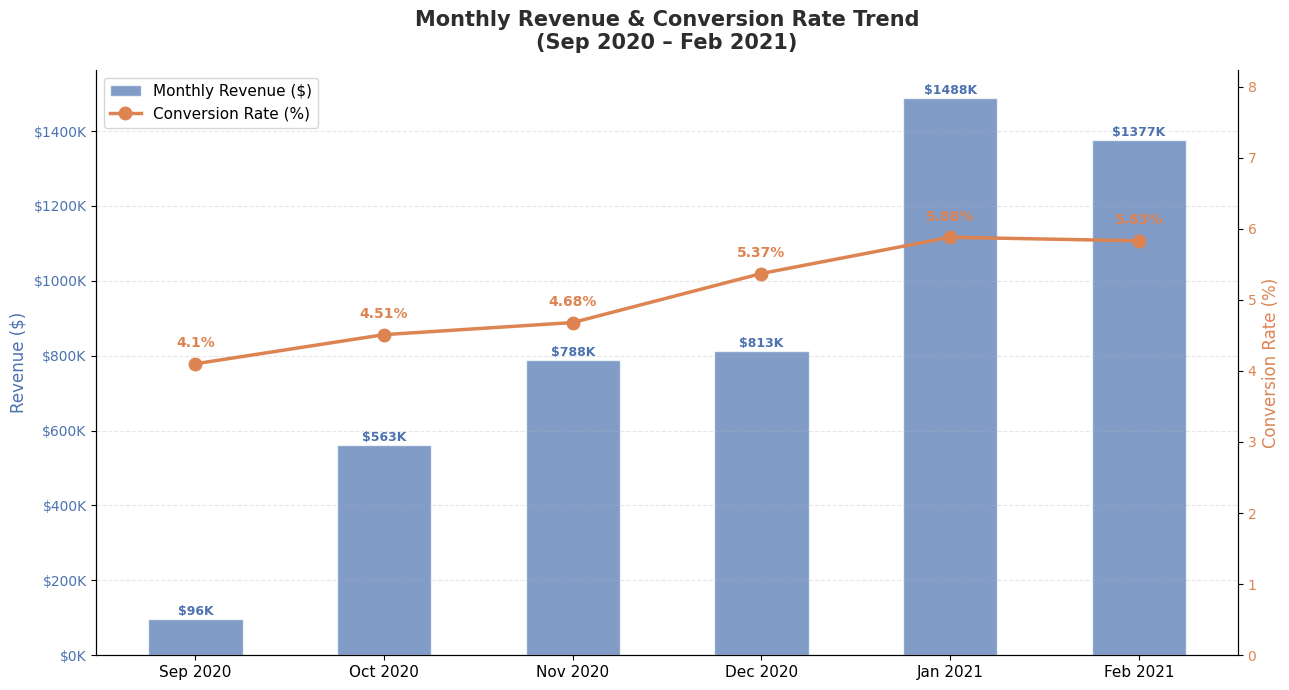

Saved.


In [15]:
# Monthly revenue + conversion dual axis
fig, ax1 = plt.subplots(figsize=(13, 7))

month_labels = pd.to_datetime(monthly_df['month']).dt.strftime('%b %Y')
x = np.arange(len(monthly_df))

bars = ax1.bar(
    x, monthly_df['monthly_revenue'],
    color='#4C72B0', alpha=0.7,
    width=0.5, edgecolor='white',
    label='Monthly Revenue ($)'
)
ax1.set_ylabel('Revenue ($)', fontsize=12, color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K')
)

# Revenue labels on bars
for bar, val in zip(bars, monthly_df['monthly_revenue']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f'${val/1000:.0f}K',
        ha='center', fontsize=9,
        fontweight='bold', color='#4C72B0'
    )

ax2 = ax1.twinx()
ax2.plot(
    x, monthly_df['conversion_rate'],
    color='#DD8452', marker='o',
    linewidth=2.5, markersize=9,
    label='Conversion Rate (%)', zorder=5
)
ax2.set_ylabel('Conversion Rate (%)', fontsize=12, color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, monthly_df['conversion_rate'].max() * 1.4)

for xi, yi in zip(x, monthly_df['conversion_rate']):
    ax2.annotate(
        f'{yi}%', (xi, yi),
        textcoords='offset points',
        xytext=(0, 12), ha='center',
        fontsize=10, color='#DD8452',
        fontweight='bold'
    )

ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, fontsize=11)
ax1.set_title(
    'Monthly Revenue & Conversion Rate Trend\n(Sep 2020 – Feb 2021)',
    fontsize=15, fontweight='bold', pad=15, color='#2d2d2d'
)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/06_monthly_revenue.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

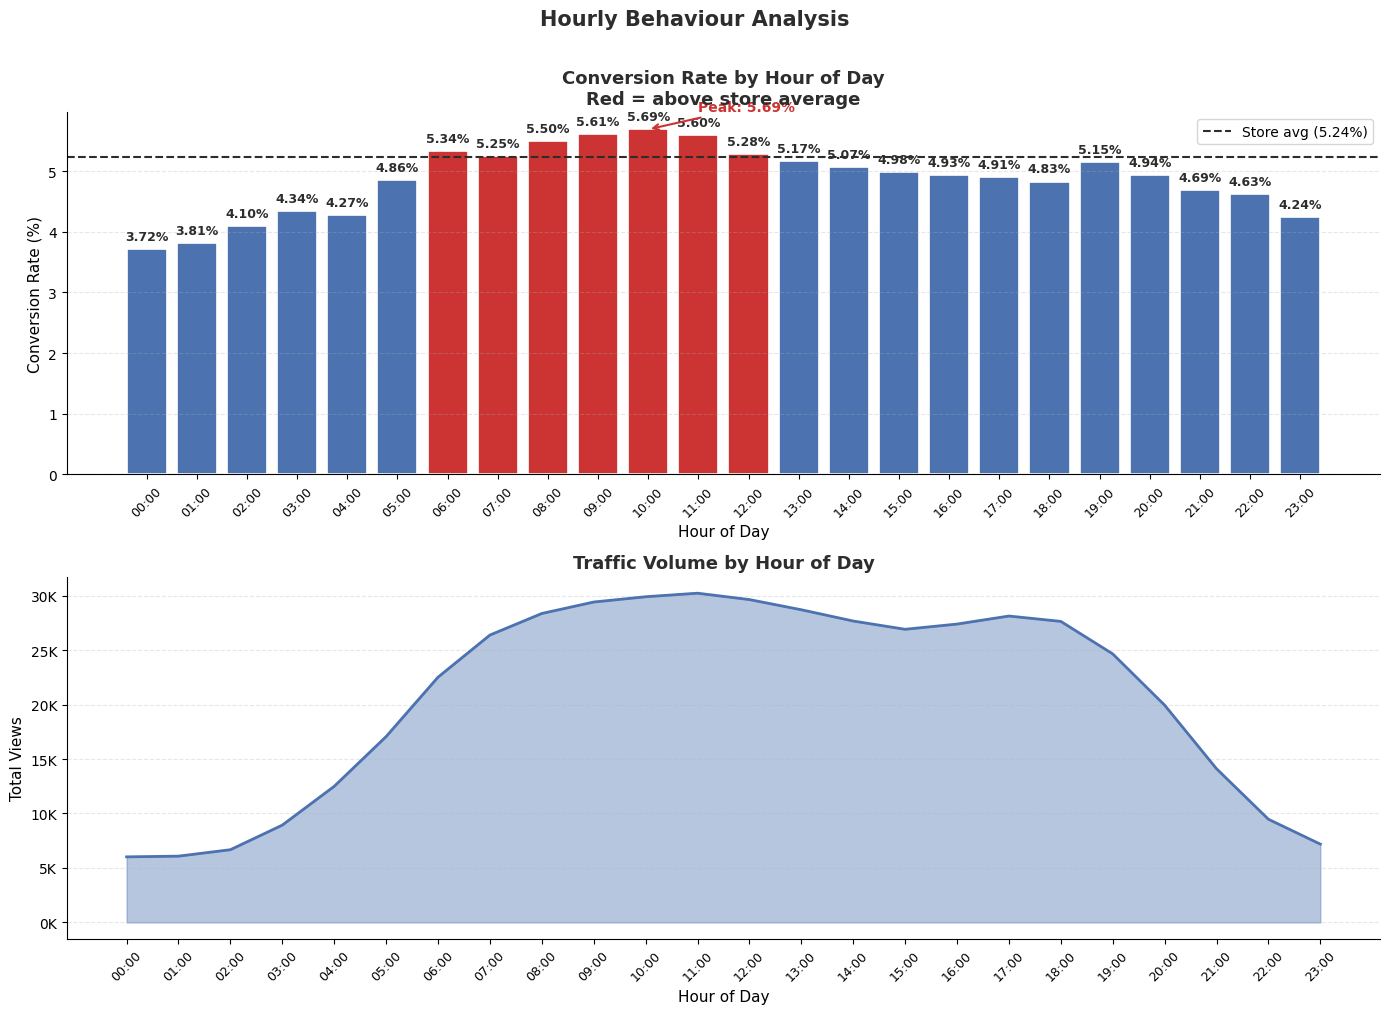

Saved.


In [16]:
# Hourly conversion heatmap style + line chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top: conversion rate by hour
colors_h = ['#cc3333' if v >= 5.24 else '#4C72B0'
            for v in hourly_df['conversion_rate']]
bars = ax1.bar(
    hourly_df['hour'],
    hourly_df['conversion_rate'],
    color=colors_h, edgecolor='white', linewidth=1.2
)

# Conversion rate labels on bars
for bar, val in zip(bars, hourly_df['conversion_rate']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,   # small offset above bar
        f'{val:.2f}%',             # correct % format
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#2d2d2d'
    )

ax1.axhline(y=5.24, color='#2d2d2d', linestyle='--',
            linewidth=1.5, label='Store avg (5.24%)')
ax1.set_title(
    'Conversion Rate by Hour of Day\nRed = above store average',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11)
ax1.set_xticks(range(0, 24))
ax1.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, fontsize=9
)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)

# Annotate peak hour
peak_hour = hourly_df.loc[hourly_df['conversion_rate'].idxmax()]
ax1.annotate(
    f"Peak: {peak_hour['conversion_rate']}%",
    xy=(peak_hour['hour'], peak_hour['conversion_rate']),
    xytext=(peak_hour['hour'] + 1, peak_hour['conversion_rate'] + 0.3),
    fontsize=10, color='#cc3333', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#cc3333', lw=1.5)
)

# Bottom: views volume by hour
ax2.fill_between(
    hourly_df['hour'],
    hourly_df['total_views'],
    alpha=0.4, color='#4C72B0', label='Total Views'
)
ax2.plot(
    hourly_df['hour'],
    hourly_df['total_views'],
    color='#4C72B0', linewidth=2
)
ax2.set_title(
    'Traffic Volume by Hour of Day',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax2.set_xlabel('Hour of Day', fontsize=11)
ax2.set_ylabel('Total Views', fontsize=11)
ax2.set_xticks(range(0, 24))
ax2.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, fontsize=9
)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}K')
)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(
    'Hourly Behaviour Analysis',
    fontsize=15, fontweight='bold',
    color='#2d2d2d', y=1.01
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/06_hourly_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

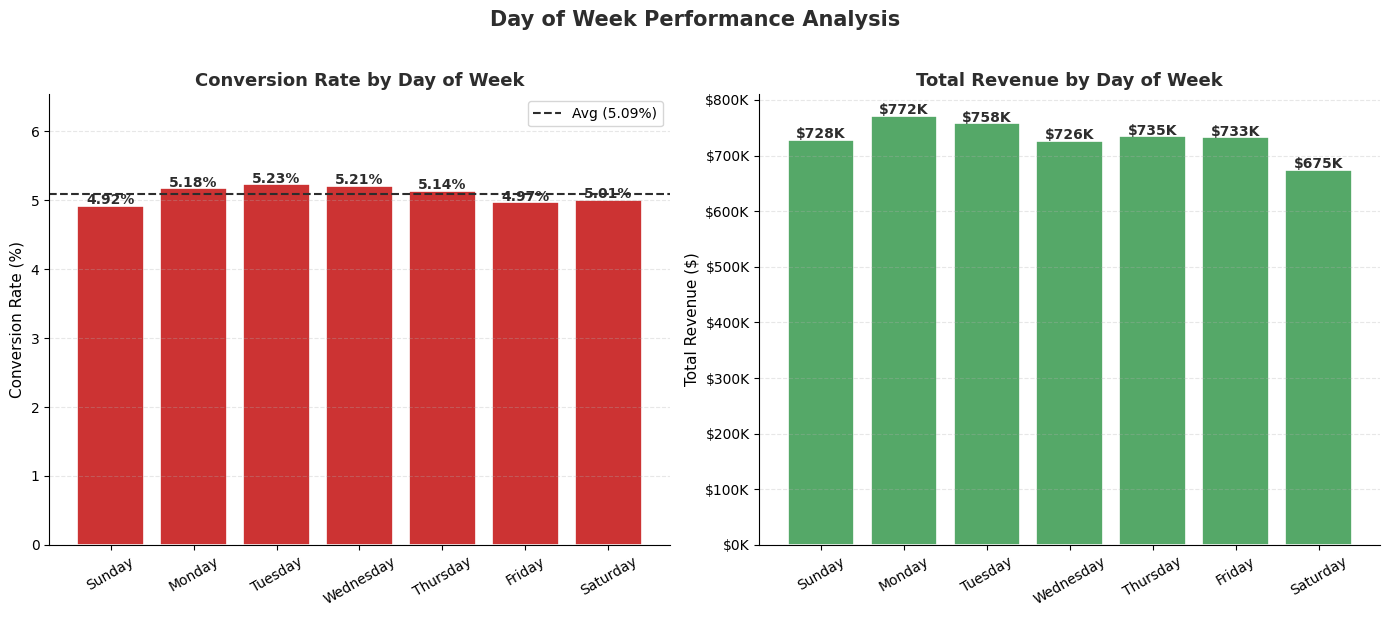

Saved.


In [17]:
# Day of week analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Conversion rate by day
colors_d = ['#cc3333' if v >= 4.76 else '#4C72B0'
            for v in dow_df['conversion_rate']]
ax1.bar(
    dow_df['day_name'],
    dow_df['conversion_rate'],
    color=colors_d, edgecolor='white', linewidth=1.2
)
ax1.axhline(
    y=dow_df['conversion_rate'].mean(),
    color='#2d2d2d', linestyle='--',
    linewidth=1.5,
    label=f"Avg ({dow_df['conversion_rate'].mean():.2f}%)"
)
for i, (day, val) in enumerate(
        zip(dow_df['day_name'], dow_df['conversion_rate'])):
    ax1.text(i, val + 0.02, f'{val}%',
             ha='center', fontsize=10,
             fontweight='bold', color='#2d2d2d')
ax1.set_title(
    'Conversion Rate by Day of Week',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11)
ax1.set_ylim(0, dow_df['conversion_rate'].max() * 1.25)
ax1.tick_params(axis='x', rotation=30)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)

# Revenue by day
ax2.bar(
    dow_df['day_name'],
    dow_df['total_revenue'],
    color='#55A868', edgecolor='white', linewidth=1.2
)
for i, (day, val) in enumerate(
        zip(dow_df['day_name'], dow_df['total_revenue'])):
    ax2.text(i, val + 3000, f'${val/1000:.0f}K',
             ha='center', fontsize=10,
             fontweight='bold', color='#2d2d2d')
ax2.set_title(
    'Total Revenue by Day of Week',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax2.set_ylabel('Total Revenue ($)', fontsize=11)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K')
)
ax2.tick_params(axis='x', rotation=30)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(
    'Day of Week Performance Analysis',
    fontsize=15, fontweight='bold',
    color='#2d2d2d', y=1.02
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/06_day_of_week.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

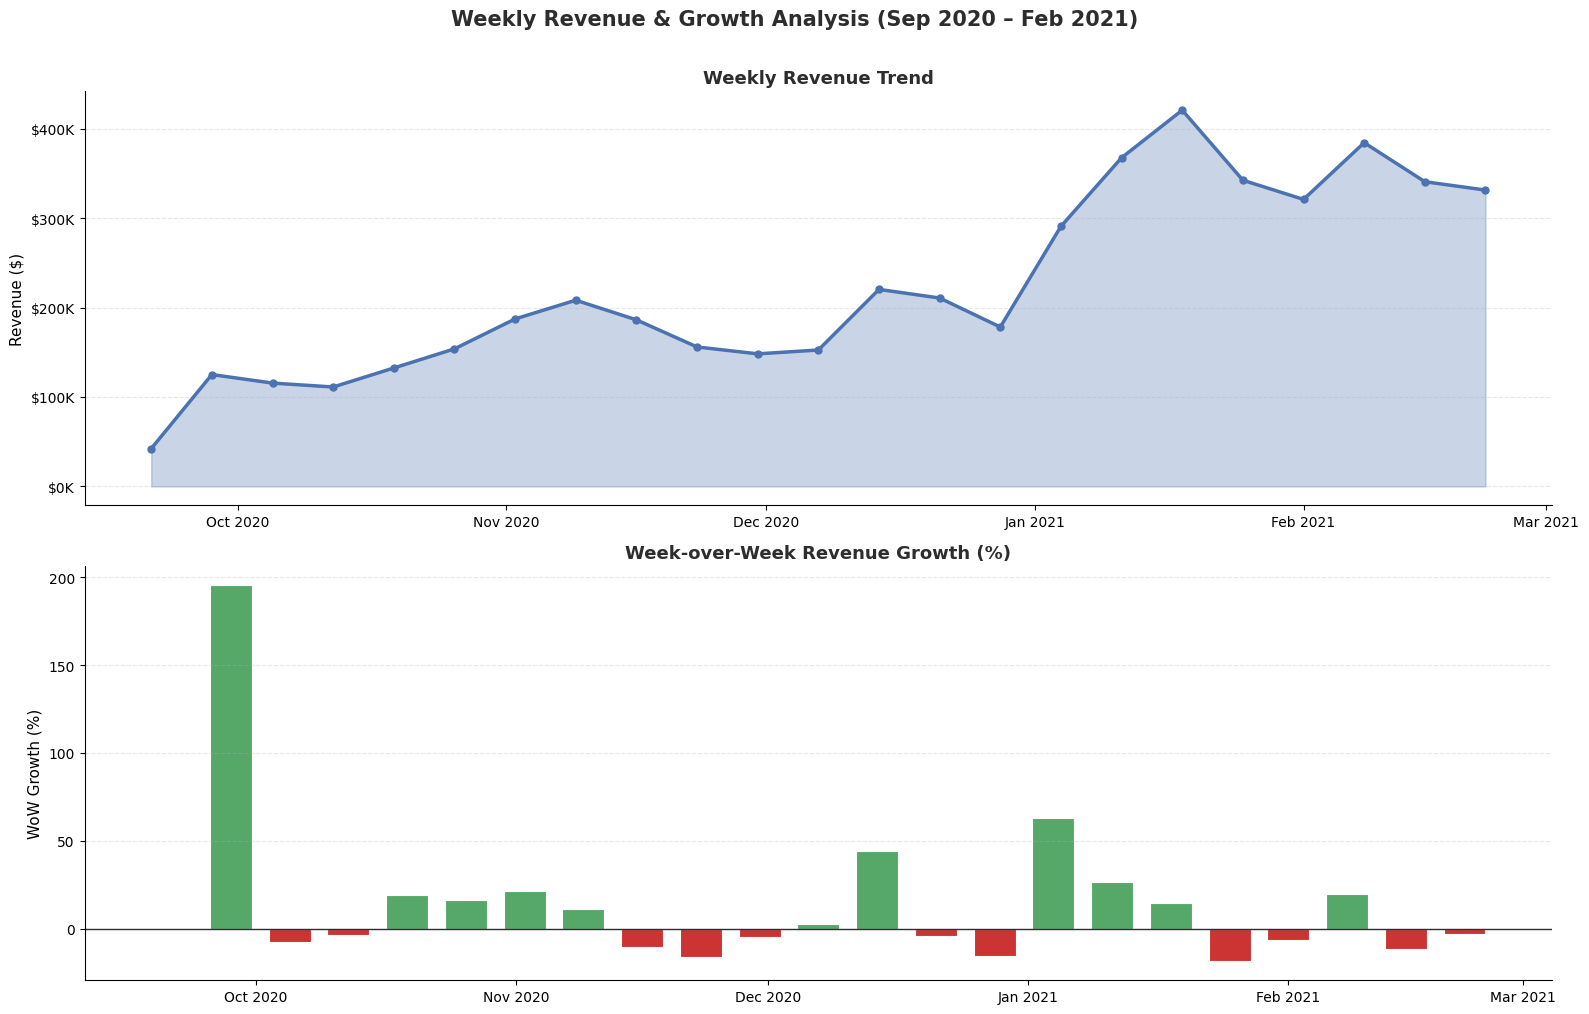

Saved.


In [18]:
# Weekly revenue growth (WoW)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Top: weekly revenue trend
ax1.fill_between(
    weekly_df['week_start'],
    weekly_df['revenue'],
    alpha=0.3, color='#4C72B0'
)
ax1.plot(
    weekly_df['week_start'],
    weekly_df['revenue'],
    color='#4C72B0', linewidth=2.5,
    marker='o', markersize=5
)
ax1.set_title(
    'Weekly Revenue Trend',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax1.set_ylabel('Revenue ($)', fontsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K')
)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Bottom: WoW growth %
wow = weekly_df.dropna(subset=['revenue_growth_pct']).copy()
colors_w = ['#55A868' if v >= 0 else '#cc3333'
            for v in wow['revenue_growth_pct']]
ax2.bar(
    wow['week_start'],
    wow['revenue_growth_pct'],
    color=colors_w, width=5,
    edgecolor='white', linewidth=0.8
)
ax2.axhline(y=0, color='#2d2d2d', linewidth=1)
ax2.set_title(
    'Week-over-Week Revenue Growth (%)',
    fontsize=13, fontweight='bold', color='#2d2d2d'
)
ax2.set_ylabel('WoW Growth (%)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(
    'Weekly Revenue & Growth Analysis (Sep 2020 – Feb 2021)',
    fontsize=15, fontweight='bold',
    color='#2d2d2d', y=1.01
)
plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/06_weekly_growth.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")

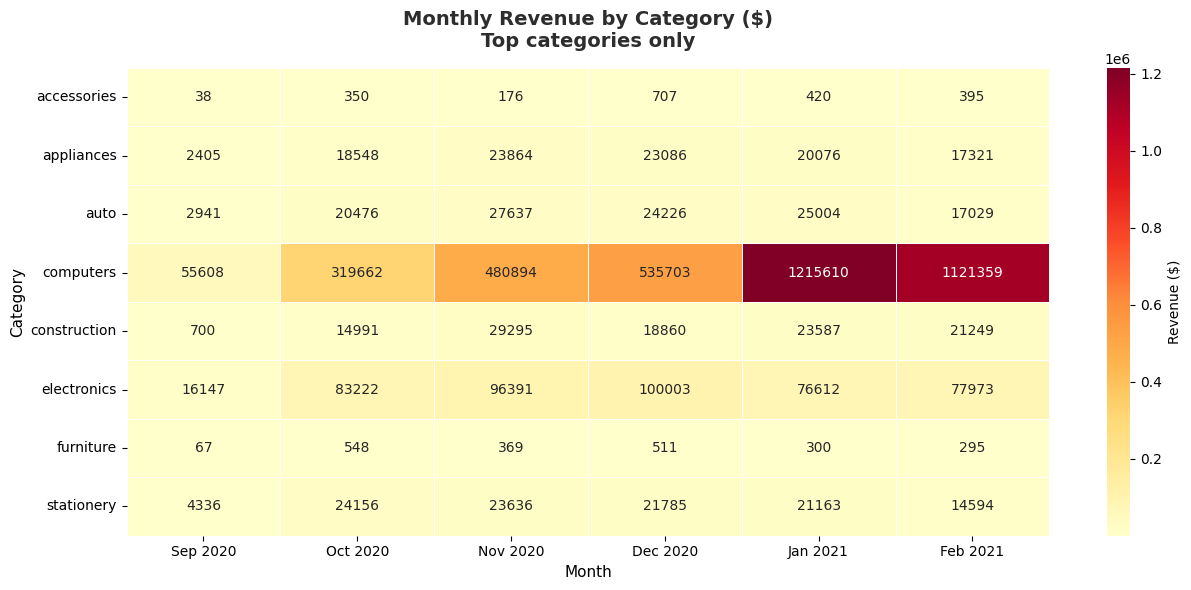

Saved.


In [19]:
# Monthly category heatmap
query_cat_monthly = """
SELECT
    TO_CHAR(DATE_TRUNC('month', event_time), 'Mon YYYY') AS month,
    DATE_TRUNC('month', event_time)                      AS month_sort,
    category_l1,
    ROUND(SUM(price) FILTER
          (WHERE event_type = 'purchase'), 2)            AS monthly_revenue
FROM events_clean
WHERE category_l1 IS NOT NULL
  AND category_l1 NOT IN (
      'apparel', 'jewelry', 'sport',
      'kids', 'medicine', 'country_yard'
  )
GROUP BY month, month_sort, category_l1
ORDER BY month_sort;
"""
cat_monthly_df = pd.read_sql(query_cat_monthly, engine)

pivot = cat_monthly_df.pivot_table(
    index='category_l1',
    columns='month',
    values='monthly_revenue',
    aggfunc='sum'
).fillna(0)

# Sort columns by date
month_order = (cat_monthly_df
               .drop_duplicates('month')
               .sort_values('month_sort')['month']
               .tolist())
pivot = pivot[month_order]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Revenue ($)'}
)
ax.set_title(
    'Monthly Revenue by Category ($)\nTop categories only',
    fontsize=14, fontweight='bold', pad=15, color='#2d2d2d'
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Category', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(
    'D:/Projects/e-commerce_funnel_analysis/images/06_category_monthly_heatmap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved.")